In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

In [2]:
DATA_DIR = Path("../data/split")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

IMG_SIZE = (224, 224)

In [3]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

Found 5396 files belonging to 6 classes.
Found 1156 files belonging to 6 classes.
Found 1157 files belonging to 6 classes.


In [ ]:
def apply_clahe(image):
    
    image = image.numpy().astype(np.uint8)

    # RGB → LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # ambil channel L
    l, a, b = cv2.split(lab)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    cl = clahe.apply(l)

    # gabungkan kembali
    enhanced_lab = cv2.merge((cl, a, b))

    # LAB → RGB
    enhanced_rgb = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2RGB
    )

    return enhanced_rgb

In [5]:
def apply_gaussian(image):

    blurred = cv2.GaussianBlur(
        image,
        (3,3),
        0
    )

    return blurred

In [1]:
def enhance_image(image):

    clahe_result = apply_clahe(image)

    gaussian_result = apply_gaussian(
        clahe_result
    )

    return gaussian_result

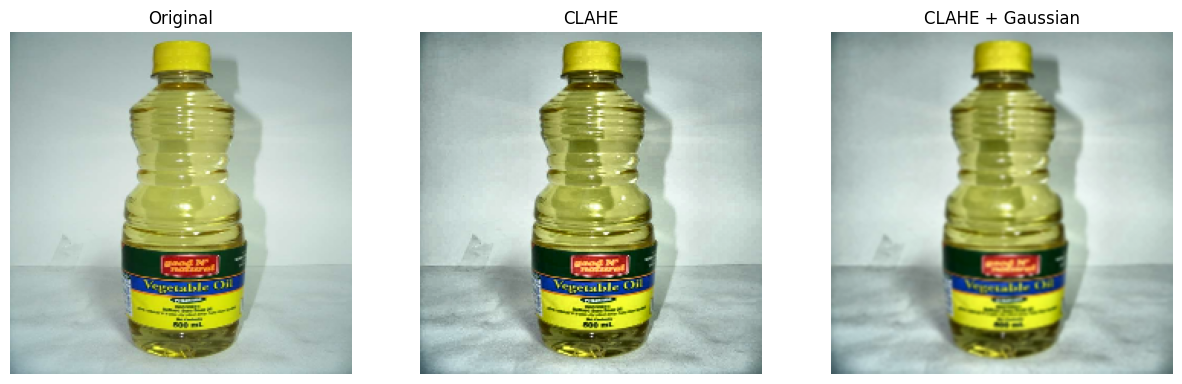

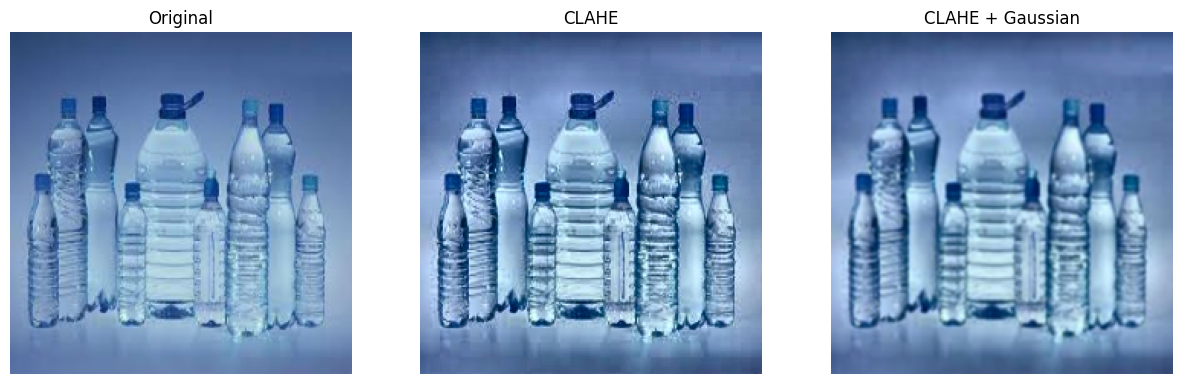

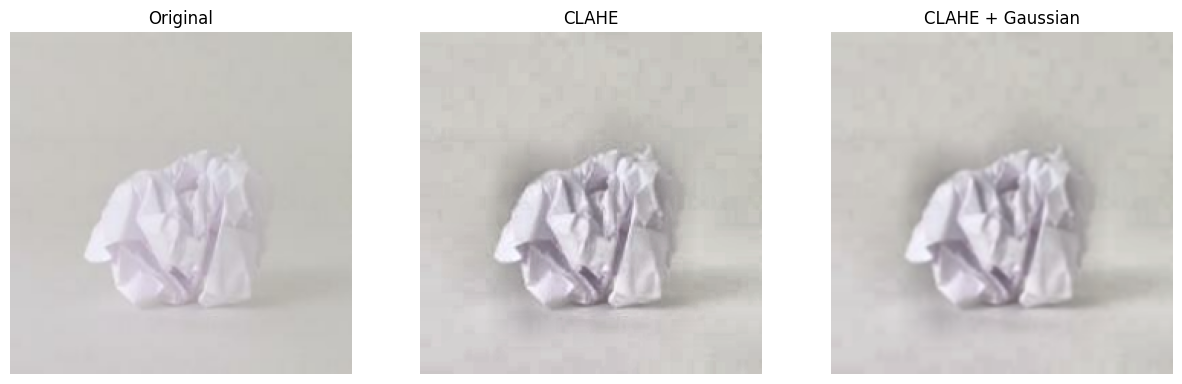

In [7]:
for images, labels in train_dataset.take(3):

    sample_image = images[0]

    enhanced_image = enhance_image(sample_image)

    plt.figure(figsize=(15,5))

    # gambar asli
    plt.subplot(1,3,1)
    plt.imshow(sample_image.numpy().astype("uint8"))
    plt.title("Original")
    plt.axis("off")

    # CLAHE
    plt.subplot(1,3,2)
    plt.imshow(apply_clahe(sample_image))
    plt.title("CLAHE")
    plt.axis("off")

    # Gaussian
    plt.subplot(1,3,3)
    plt.imshow(enhanced_image)
    plt.title("CLAHE + Gaussian")
    plt.axis("off")

    plt.show()